# Bulk TCR immune-repertoire analysis with `ov.airr`

Adaptive immunity is written into the **T-cell receptor (TCR) repertoire** — the
collection of clonally rearranged TCRs carried by an individual's T cells. In
**bulk AIRR-seq** we amplify and sequence the TCR-beta CDR3 region from a whole
T-cell population, so each repertoire is a *table of clonotypes* with abundances,
rather than a per-cell matrix. The shape of that table — how diverse it is, how
clonally skewed, which clonotypes are shared between people — is a quantitative
readout of an immune state.

This tutorial runs a complete bulk-repertoire study with `ov.airr`, the
omicverse immune-repertoire suite. `ov.airr` wraps the `pyimmunarch` backend
(an R-parity reimplementation of `immunarch`) behind a registered, dispatch-based
API: `repertoire_diversity`, `clonality`, `repertoire_overlap_bulk`,
`public_clonotypes`, `gene_usage_bulk` and `track_clonotypes`.

**The cohort.** We use the canonical `immunarch` example dataset shipped inside
`pyimmunarch` — a **12-sample TCR-beta cohort**: **6 multiple-sclerosis (MS)
patients** and **6 healthy controls**. MS is an autoimmune disease of the central
nervous system, so a natural question is whether the peripheral TCR repertoire
of MS patients differs systematically from that of healthy donors.

**The questions a bulk repertoire study answers:**

- **Diversity** — how many distinct clonotypes, and how evenly distributed?
- **Clonality** — is the repertoire dominated by a few expanded clones?
- **Overlap & public clonotypes** — which TCRs are shared across individuals?
- **Gene usage** — are particular V-gene segments over-used in disease?
- **Clonal tracking** — how do specific clonotypes behave across samples?

In [1]:
import omicverse as ov
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ov.plot_set()

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
🚫 No GPU devices found (CUDA/MPS/ROCm/XPU)

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1. Load the bulk TCR cohort

`ov.airr.load_example_immdata()` returns a `pyimmunarch.ImmunData` object — the
*immunarch* data model. It has two parts:

- `.data` — an ordered dict mapping each **sample name** to its **repertoire
  table** (one row per clonotype, with `Clones`, `Proportion`, `CDR3.aa`,
  `V.name`, `D.name`, `J.name`, …).
- `.meta` — a sample-level metadata table carrying the **MS / healthy `Status`**,
  plus `Sex`, `Age` and sequencing `Lane`.

The loader also repairs the per-sample count columns if the bundled files leave
them empty, so the count-dependent analyses below run cleanly.

In [2]:
immdata = ov.airr.load_example_immdata()
print(f"samples: {len(immdata.data)}")
print(f"sample names: {list(immdata.data)}")
immdata.meta

samples: 12
sample names: ['A2-i129', 'A2-i131', 'A2-i132', 'A2-i133', 'A4-i191', 'A4-i192', 'MS1', 'MS2', 'MS3', 'MS4', 'MS5', 'MS6']


,Sample,ID,Sex,Age,Status,Lane
0,A2-i129,C1,M,11,C,A
1,A2-i131,C2,M,9,C,A
2,A2-i133,C4,M,16,C,A
3,A2-i132,C3,F,6,C,A
4,A4-i191,C8,F,22,C,B
5,A4-i192,C9,F,24,C,B
6,MS1,MS1,M,12,MS,C
7,MS2,MS2,M,30,MS,C
8,MS3,MS3,M,8,MS,C
9,MS4,MS4,F,14,MS,C


The `Status` column splits the cohort cleanly: **`MS`** are the 6 multiple-sclerosis
patients, **`C`** are the 6 healthy controls. We build an explicit MS-vs-healthy
grouping that the rest of the notebook reuses, and add a readable `group` label.

In [3]:
cohort = ov.airr.cohort_groups(immdata, status_col="Status",
                            mapping={"MS": "MS", "C": "Healthy"})
meta = cohort["meta"]
ms_samples = cohort["groups"]["MS"]
hc_samples = cohort["groups"]["Healthy"]
print(f"MS patients ({len(ms_samples)}): {ms_samples}")
print(f"healthy    ({len(hc_samples)}): {hc_samples}")


MS patients (6): ['MS1', 'MS2', 'MS3', 'MS4', 'MS5', 'MS6']
healthy    (6): ['A2-i129', 'A2-i131', 'A2-i133', 'A2-i132', 'A4-i191', 'A4-i192']


## 2. Repertoire exploration

Before any statistics, look at the raw shape of each repertoire. Two basic
descriptors:

- **Unique clonotypes per sample** — the number of rows in each repertoire
  table, i.e. how many distinct TCR-beta CDR3s were observed.
- **Total clones** — the summed `Clones` count (sequencing depth has been
  equalised across samples in this dataset, so differences in *unique*
  clonotypes reflect biology, not depth).

In [4]:
explore = ov.airr.repertoire_summary(immdata, meta=meta)
explore


,unique_clonotypes,total_clones,group
A2-i129,6532,8500,Healthy
A2-i131,6553,8500,Healthy
A2-i132,6849,8500,Healthy
A2-i133,6393,8500,Healthy
A4-i191,5146,8500,Healthy
A4-i192,5823,8500,Healthy
MS1,5405,8500,MS
MS2,7145,8500,MS
MS3,6461,8500,MS
MS4,7447,8500,MS


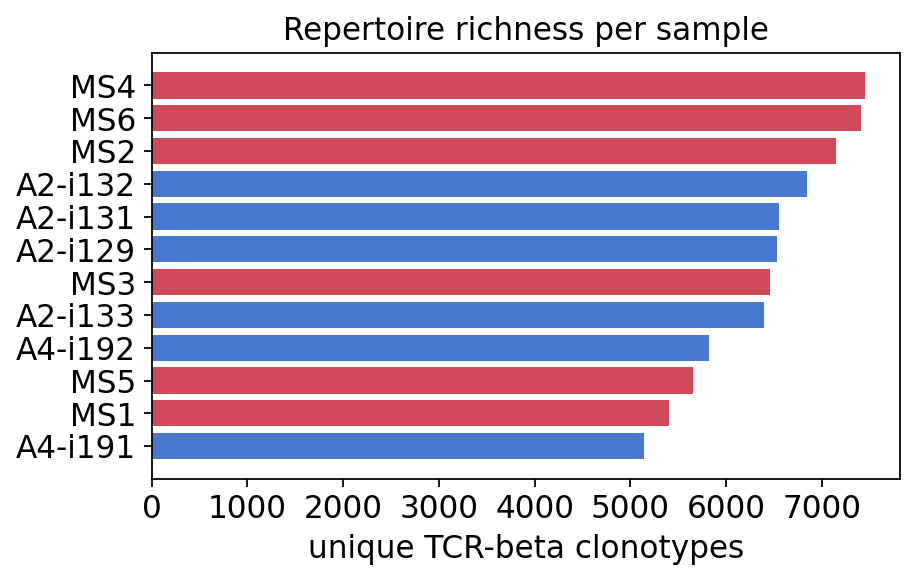

In [5]:
fig, ax = plt.subplots(figsize=(6, 3.5))
colors = {"MS": "#d1495b", "Healthy": "#4878cf"}
order = explore.sort_values("unique_clonotypes").index
ax.barh(range(len(order)), explore.loc[order, "unique_clonotypes"],
        color=[colors[g] for g in explore.loc[order, "group"]])
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order)
ax.set_xlabel("unique TCR-beta clonotypes")
ax.set_title("Repertoire richness per sample")
plt.show()

### CDR3-length spectratype

The **spectratype** is the distribution of CDR3 amino-acid lengths, weighted by
clone abundance. A healthy polyclonal repertoire shows a smooth, roughly
Gaussian length distribution centred near 14–15 aa; sharp distortions can signal
clonal skewing. We compute it per group by pooling clone counts at each length.

In [6]:
spec = ov.airr.spectratype_bulk(immdata, groupby=cohort["groups"])
spec_ms, spec_hc = spec["MS"].dropna(), spec["Healthy"].dropna()
print(f"CDR3-length spectratype: MS peak {spec_ms.idxmax()} aa, "
      f"healthy peak {spec_hc.idxmax()} aa")


CDR3-length spectratype: MS peak 15 aa, healthy peak 14 aa


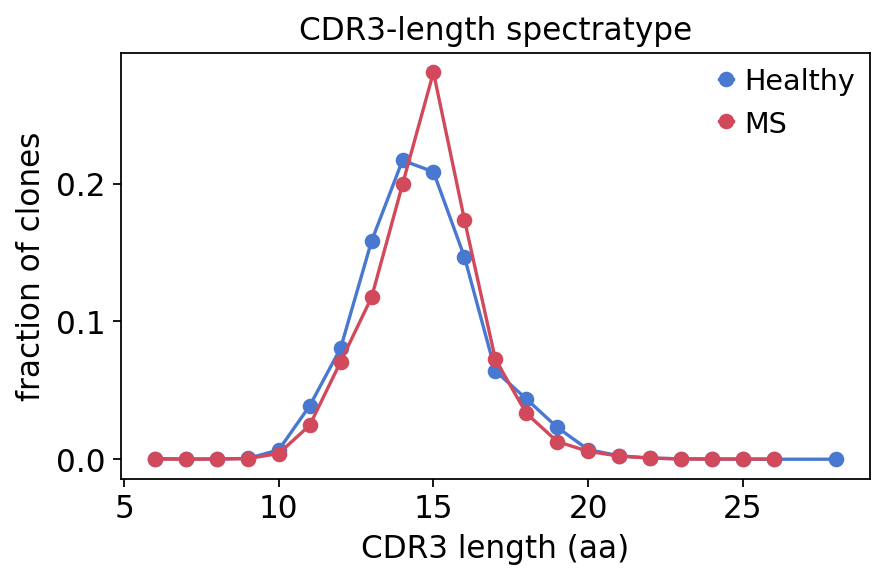

In [7]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(spec_hc.index, spec_hc.values, "o-", color=colors["Healthy"], label="Healthy")
ax.plot(spec_ms.index, spec_ms.values, "o-", color=colors["MS"], label="MS")
ax.set_xlabel("CDR3 length (aa)")
ax.set_ylabel("fraction of clones")
ax.set_title("CDR3-length spectratype")
ax.legend(frameon=False)
plt.show()

Both groups show the canonical bell-shaped spectratype peaking at 14–15 aa, with
no gross length distortion — the repertoires are polyclonal in both groups, so
any disease signal will be quantitative (diversity, clonality, gene usage)
rather than a coarse structural defect.

## 3. Clonality — is the repertoire dominated by a few clones?

**Clonality** measures how unequally sequencing reads are distributed across
clonotypes. `ov.airr.clonality` wraps `pyimmunarch.repClonality` with several
`method` views:

- `method='top'` — cumulative proportion held by the *N* most-abundant clones.
- `method='homeo'` — **clonal-space homeostasis**: the fraction of the
  repertoire occupied by Rare / Small / Medium / Large / Hyperexpanded clones.

A repertoire skewed toward a few large clones (high top-clone proportion, large
Hyperexpanded fraction) has *low* effective diversity.

In [8]:
top_clones = ov.airr.clonality(immdata, method="top")
top10 = top_clones.iloc[:, 0].rename("top10_proportion").to_frame()
ov.airr.summarize_by_group(top10, group=meta.set_index("Sample")["group"],
                           value="top10_proportion",
                           agg=["mean", "min", "max"])


top10_proportion                    
                    mean       min       max
group                                       
Healthy         0.093824  0.023882  0.171765
MS              0.109804  0.023294  0.206118

In [9]:
homeo = ov.airr.clonality(immdata, method="homeo")
homeo_by_group = ov.airr.summarize_by_group(
    homeo, group=meta.set_index("Sample")["group"], agg="mean")
homeo_by_group


,Rare (0 < X <= 1e-05),Small (1e-05 < X <= 1e-04),Medium (1e-04 < X <= 1e-03),Large (1e-03 < X <= 1e-02),Hyperexpanded (1e-02 < X <= 1)
group,,,,,
Healthy,0.0,0.0,0.849196,0.091882,0.058922
MS,0.0,0.0,0.856392,0.064941,0.078667


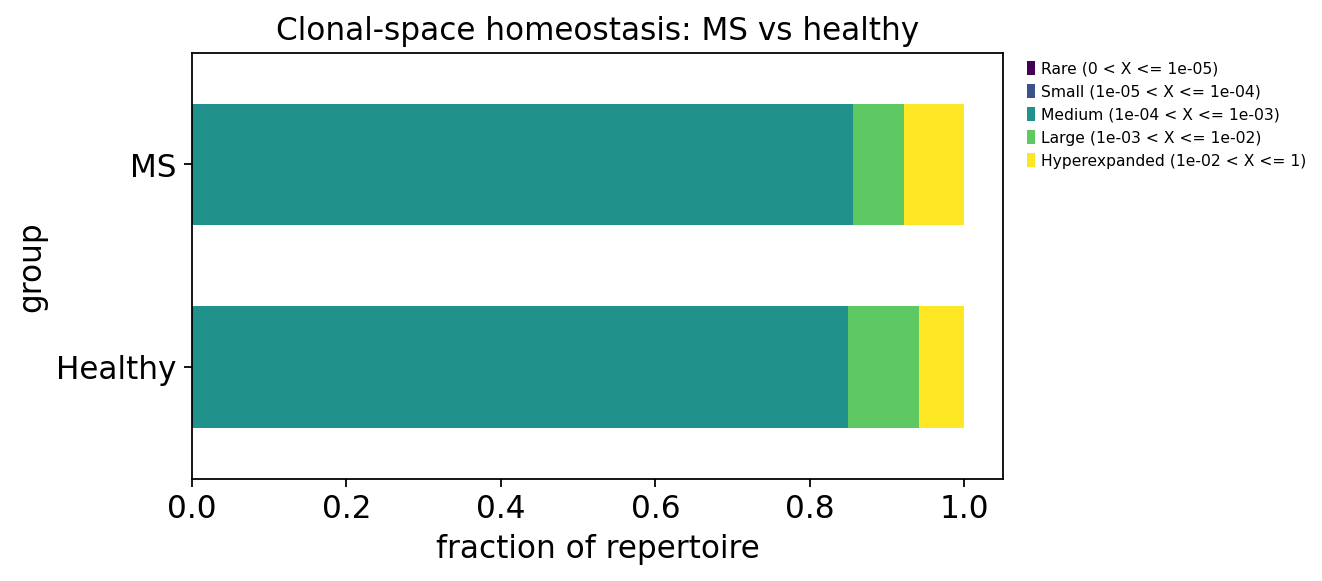

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 3.5))
homeo_by_group.plot(kind="barh", stacked=True, ax=ax, colormap="viridis", width=0.6)
ax.set_xlabel("fraction of repertoire")
ax.set_title("Clonal-space homeostasis: MS vs healthy")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7, frameon=False)
plt.show()

The top-10-clone proportion and the **Hyperexpanded** clonal-space fraction are,
on average, **higher and far more variable in the MS group** — several MS
patients carry strongly expanded T-cell clones, whereas healthy controls keep a
flatter clone-size distribution. Clonal expansion is heterogeneous within MS,
which is consistent with autoimmune T-cell expansions being patient-specific.

## 4. Repertoire diversity

Diversity is the complement of clonality — a flat, even repertoire is *diverse*.
`ov.airr.repertoire_diversity` (over `pyimmunarch.repDiversity`) offers several
estimators via `method`:

- `chao1` — a richness estimator that **extrapolates unseen clonotypes** from
  the singleton/doubleton tail; robust to incomplete sampling.
- `hill` — **Hill numbers** $^qD$: a continuum of diversity indices indexed by
  the order $q$. $q{=}0$ is richness, $q{=}1$ is exponential Shannon, larger $q$
  weights abundant clones more — the curve's shape encodes evenness.
- `d50` — the number of top clonotypes needed to cover 50% of the repertoire
  (smaller = more clonally skewed).

In [11]:
chao1 = ov.airr.repertoire_diversity(immdata, method="chao1")
chao1 = chao1.join(meta.set_index("Sample")[["group"]])
ov.airr.summarize_by_group(chao1, group="group", value="Estimator",
                           agg=["mean", "std"])


Estimator              
                 mean           std
group                              
Healthy  40689.395042   7999.299275
MS       68678.298416  21989.281690

In [12]:
d50 = ov.airr.repertoire_diversity(immdata, method="d50")
d50 = d50.join(meta.set_index("Sample")[["group"]])
ov.airr.summarize_by_group(d50, group="group", value="Clones",
                           agg=["mean", "min", "max"])


Clones                
                mean     min     max
group                               
Healthy  1878.666667   861.0  2393.0
MS       2305.500000  1111.0  3159.0

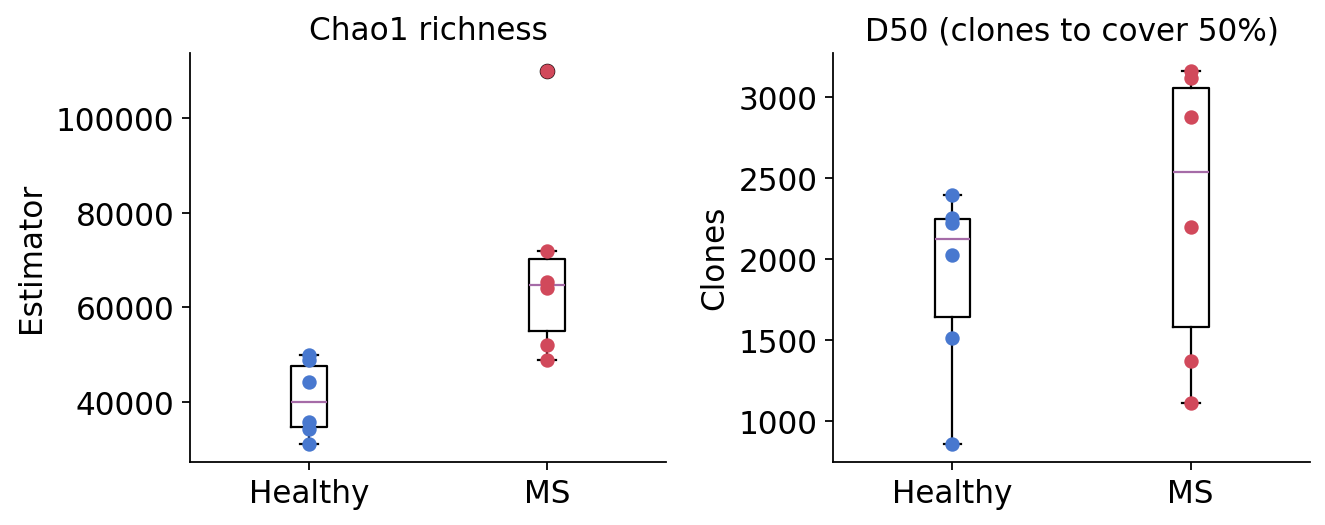

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.5))
ov.airr.group_box_plot(chao1, value="Estimator", group="group",
                       order=["Healthy", "MS"], ax=axes[0],
                       title="Chao1 richness", palette=colors)
ov.airr.group_box_plot(d50, value="Clones", group="group",
                       order=["Healthy", "MS"], ax=axes[1],
                       title="D50 (clones to cover 50%)", palette=colors)
plt.tight_layout()
plt.show()


### Hill-number diversity profile

Plotting $^qD$ against the order $q$ gives a **diversity profile**: a curve that
starts at richness ($q{=}0$) and falls as abundant clones are up-weighted. A
profile that drops steeply belongs to a clonally skewed repertoire.

In [14]:
hill = ov.airr.repertoire_diversity(immdata, method="hill")
hill = hill.merge(meta[["Sample", "group"]], on="Sample")
hill_profile = ov.airr.summarize_by_group(
    hill, group=["group", "Q"], value="Value", agg="mean", pivot="group")
hill_profile.columns = hill_profile.columns.droplevel(0)
hill_profile


group,Healthy,MS
Q,,
1,3864.967000,4264.817350
2,1107.316904,1758.151055
3,467.964705,723.051209
4,285.296948,414.225282
5,211.362082,301.823245
6,173.527488,247.319992


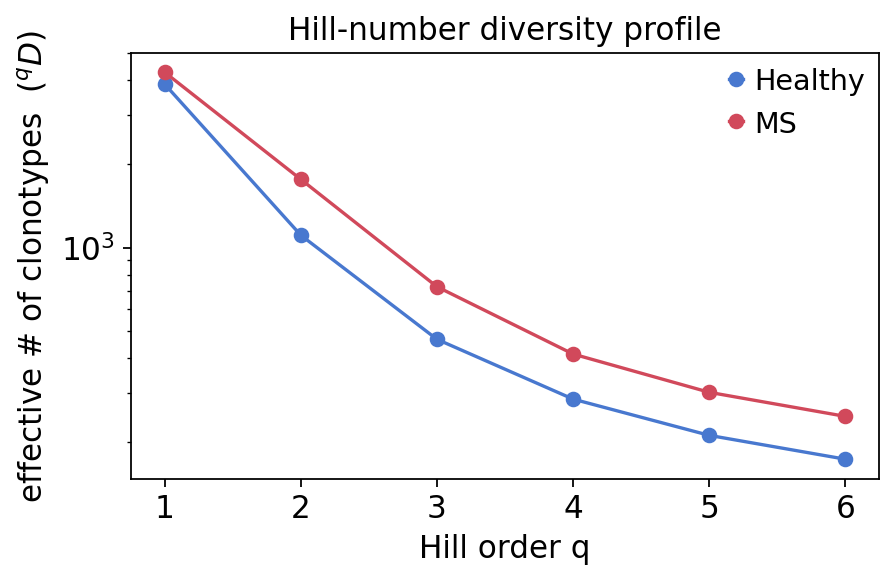

In [15]:
fig, ax = plt.subplots(figsize=(6, 3.5))
for g in ["Healthy", "MS"]:
    ax.plot(hill_profile.index, hill_profile[g], "o-", color=colors[g], label=g)
ax.set_xlabel("Hill order q")
ax.set_ylabel("effective # of clonotypes  ($^qD$)")
ax.set_yscale("log")
ax.set_title("Hill-number diversity profile")
ax.legend(frameon=False)
plt.show()

### Rarefaction

`method='raref'` computes a **rarefaction curve** — observed diversity as a
function of sub-sampled sequencing depth. Because depth is equalised in this
cohort, rarefaction curves let us compare *richness accumulation* fairly: a
curve that rises faster and higher is the more diverse repertoire.

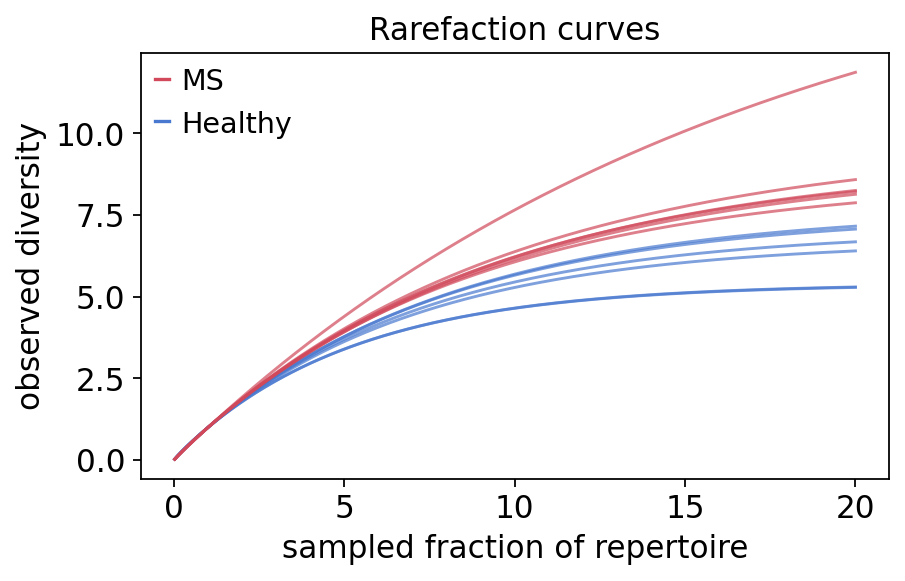

In [16]:
raref = ov.airr.repertoire_diversity(immdata, method="raref")
raref = raref.merge(meta[["Sample", "group"]], on="Sample")

fig, ax = plt.subplots(figsize=(6, 3.5))
for s, sub in raref.groupby("Sample"):
    ax.plot(sub["Size"], sub["Mean"],
            color=colors[sub["group"].iloc[0]], alpha=0.7, lw=1.3)
for g in ["MS", "Healthy"]:
    ax.plot([], [], color=colors[g], label=g)
ax.set(xlabel="sampled fraction of repertoire",
       ylabel="observed diversity", title="Rarefaction curves")
ax.legend(frameon=False)
plt.show()


The Chao1 estimator places **mean richness higher in the MS group**, and the MS
group spans a much wider range — MS3 in particular is an extreme outlier. D50 is
also larger on average in MS (more clones needed to reach 50% coverage). The
Hill profile and rarefaction curves agree: at low order $q$ MS repertoires are
at least as rich as healthy ones, but the steeper fall-off of some MS curves at
high $q$ reflects the hyperexpanded clones seen in section 3. In short — **MS
repertoires are not less diverse; they are more heterogeneous**, mixing high
underlying richness with patient-specific clonal expansions.

## 5. Repertoire overlap & public clonotypes

Most TCRs are **private** — unique to one individual. A minority are **public**:
the same CDR3 arises independently in many people, often because it is easy to
generate or under shared selective pressure. Two complementary tools:

- `ov.airr.repertoire_overlap_bulk` — a pairwise sample × sample overlap matrix.
  `method='public'` counts shared clonotypes; `method='jaccard'` normalises by
  repertoire size.
- `ov.airr.public_clonotypes` — the **public-repertoire table**: every
  clonotype with the number of samples it appears in.

In [17]:
overlap = ov.airr.repertoire_overlap_bulk(immdata, method="public")
overlap = overlap.loc[hc_samples + ms_samples, hc_samples + ms_samples]
overlap.round(0).iloc[:5, :5]

,A2-i129,A2-i131,A2-i133,A2-i132,A4-i191
A2-i129,NaN,63.0,74.0,69.0,46.0
A2-i131,63.0,NaN,56.0,81.0,42.0
A2-i133,74.0,56.0,NaN,87.0,49.0
A2-i132,69.0,81.0,87.0,NaN,62.0
A4-i191,46.0,42.0,49.0,62.0,NaN


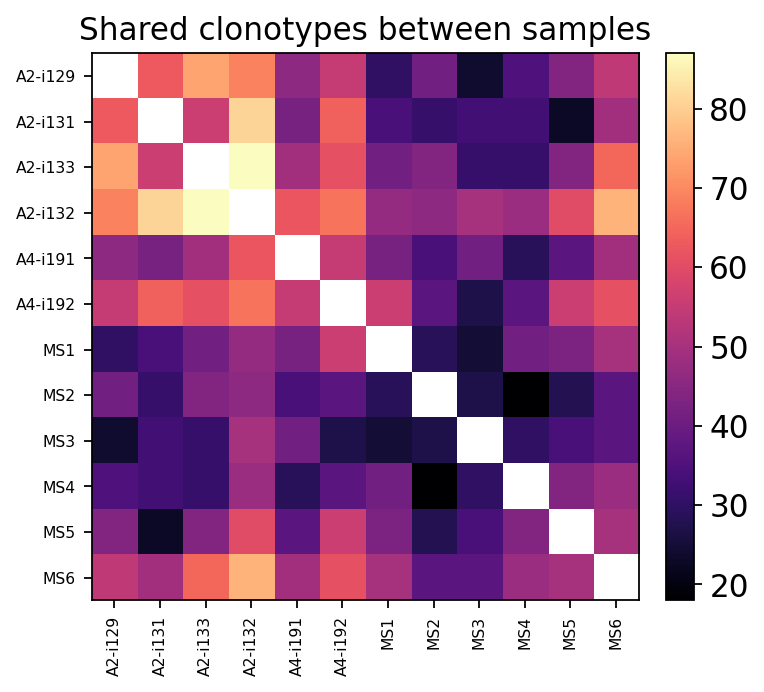

In [18]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(overlap.values, cmap="magma")
ax.set_xticks(range(len(overlap)))
ax.set_xticklabels(overlap.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(overlap)))
ax.set_yticklabels(overlap.index, fontsize=7)
ax.set_title("Shared clonotypes between samples")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

### Morisita-Horn — the depth-robust comparison

The `public` matrix above counts how many clonotypes two samples share —
useful, but **sensitive to sample depth**: a sample with twice the reads
carries twice the rare clonotypes and naively appears more 'public'.
The **Morisita-Horn (MH)** index normalises by clone abundance and is
essentially invariant to sample depth — it's the immunarch-canonical
overlap metric when samples differ in size. MH ranges from 0 (no shared
abundance structure) to 1 (identical repertoires).


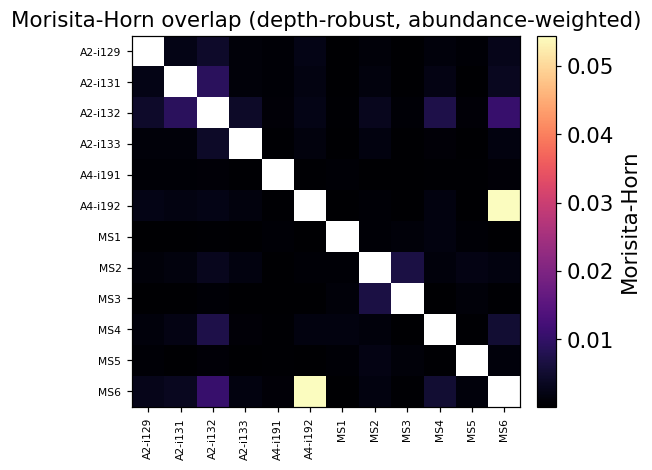

In [ ]:
mh = ov.airr.repertoire_overlap_bulk(immdata, method='morisita')
mh = mh.loc[hc_samples + ms_samples, hc_samples + ms_samples]
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(mh.values, cmap='magma', aspect='auto')
ax.set_xticks(range(len(mh.columns)))
ax.set_xticklabels(mh.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(mh.index)))
ax.set_yticklabels(mh.index, fontsize=7)
ax.set_title('Morisita-Horn overlap (depth-robust, abundance-weighted)')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Morisita-Horn')
plt.tight_layout()
plt.show()

In [19]:
pubrep = ov.airr.public_clonotypes(immdata, col="aa+v")
shared = pubrep["Samples"].value_counts().sort_index()
print(f"public-repertoire table: {pubrep.shape[0]} clonotypes")
print(f"clonotypes in all 12 samples: {(pubrep['Samples'] == 12).sum()}")
shared

public-repertoire table: 74444 clonotypes
clonotypes in all 12 samples: 0


Samples
1    73933
2      415
3       66
4       18
5        8
6        3
8        1
Name: count, dtype: int64

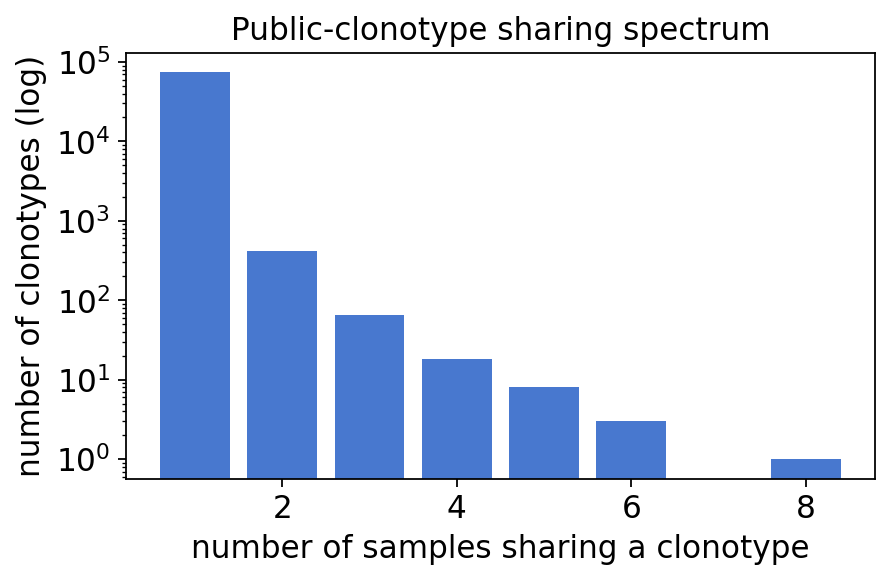

In [20]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(shared.index, shared.values, color="#4878cf")
ax.set_yscale("log")
ax.set_xlabel("number of samples sharing a clonotype")
ax.set_ylabel("number of clonotypes (log)")
ax.set_title("Public-clonotype sharing spectrum")
plt.show()

The sharing spectrum is the classic AIRR-seq shape — the **vast majority of
clonotypes are private** (seen in a single sample) and the count falls
log-linearly as the sharing level rises, yet a small **public core** is shared
across most or all 12 donors. Those highly public TCRs are convergent
recombination products; they are shared *regardless* of disease status, so they
are a poor place to look for an MS signal — the disease signal lives in gene
usage and clonal expansion instead.

## 6. V-gene usage — MS vs healthy

The V (variable) gene segment shapes the germline-encoded part of the TCR.
Skewed **V-gene usage** is one of the most reproducible repertoire-level disease
signals. `ov.airr.gene_usage_bulk` wraps `pyimmunarch.geneUsage`; with
`gene='hs.trbv'` and `norm=True` it returns a TRBV-segment × sample frequency
table. We average within each group and rank segments by the MS − healthy
difference.

In [21]:
gene_usage = ov.airr.gene_usage_bulk(immdata, gene="hs.trbv", norm=True)
gu_diff = ov.airr.differential_gene_usage(
    gene_usage, groups=cohort["groups"], case="MS", control="Healthy")
gu_diff.iloc[list(range(4)) + list(range(-4, 0))]


,Healthy,MS,delta
Names,,,
TRBV4-3,0.028401,0.011899,-0.016502
TRBV9,0.035604,0.022978,-0.012626
TRBV2,0.027394,0.017819,-0.009575
TRBV7-2,0.060213,0.051772,-0.008441
TRBV4-1,0.032536,0.041145,0.008609
TRBV6-5,0.028422,0.038060,0.009638
TRBV12-4,0.072484,0.089986,0.017502
TRBV5-1,0.065543,0.100274,0.034731


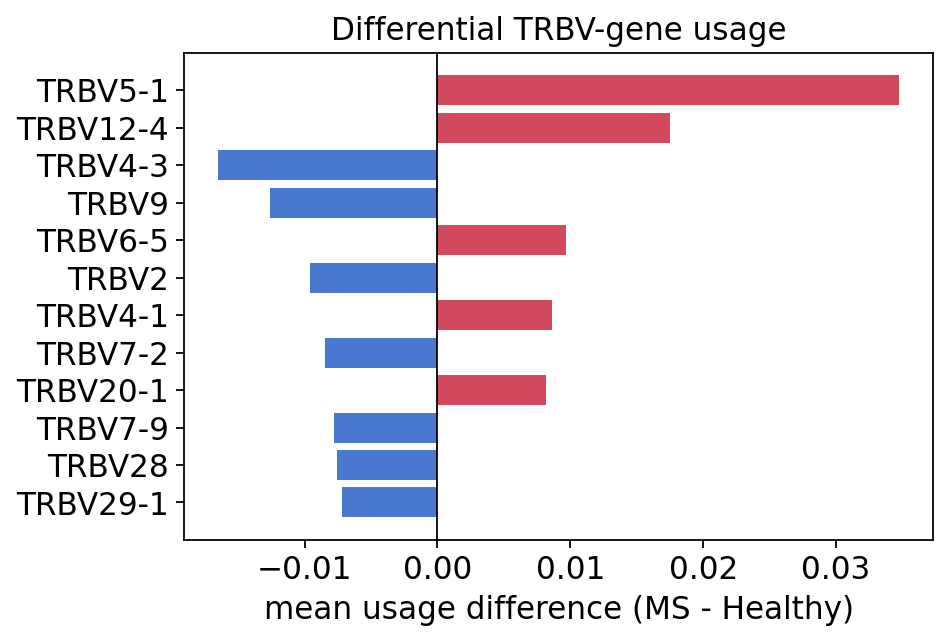

In [22]:
top_diff = gu_diff.reindex(gu_diff["delta"].abs().sort_values().index[-12:])
fig, ax = plt.subplots(figsize=(6, 4))
cols = [colors["MS"] if d > 0 else colors["Healthy"] for d in top_diff["delta"]]
ax.barh(range(len(top_diff)), top_diff["delta"], color=cols)
ax.set_yticks(range(len(top_diff)))
ax.set_yticklabels(top_diff.index)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("mean usage difference (MS - Healthy)")
ax.set_title("Differential TRBV-gene usage")
plt.show()

Several TRBV segments are differentially used: **TRBV5-1, TRBV12-4 and TRBV6-5**
are over-represented in MS patients, while **TRBV4-3 and TRBV9** are higher in
healthy controls. TRBV5-1 in particular shows the largest shift. Differential
V-gene usage is a recurring theme in autoimmune-repertoire studies — it points
to biased clonal selection rather than a global structural change.

## 7. Clonal tracking

`ov.airr.track_clonotypes` follows chosen clonotypes across every sample.
Passing `which=('MS1', 10)` selects the **10 most-abundant clonotypes of patient
MS1** and reports their frequency in all 12 repertoires (`norm=True`). This
shows whether a patient's dominant expansions are private to them or shared.

In [23]:
track = ov.airr.track_clonotypes(immdata, which=("MS1", 10), col="aa")
track_mat = track.set_index("CDR3.aa")[hc_samples + ms_samples]
track_mat.round(4)

,A2-i129,A2-i131,A2-i133,A2-i132,A4-i191,A4-i192,MS1,MS2,MS3,MS4,MS5,MS6
CDR3.aa,,,,,,,,,,,,
CASSLQAGGNTDTQYF,0.0,0.0,0.0,0.0,0.0,0.0,0.0635,0.0000,0.0000,0.0000,0.0,0.0
CASSVYSTISEQYF,0.0,0.0,0.0,0.0,0.0,0.0,0.0376,0.0000,0.0001,0.0001,0.0,0.0
CSTEEDSYNEQFF,0.0,0.0,0.0,0.0,0.0,0.0,0.0240,0.0000,0.0001,0.0000,0.0,0.0
CSVELRTESGYEQYF,0.0,0.0,0.0,0.0,0.0,0.0,0.0178,0.0000,0.0000,0.0000,0.0,0.0
CASSLGDSTYEQYF,0.0,0.0,0.0,0.0,0.0,0.0,0.0115,0.0001,0.0000,0.0001,0.0,0.0
CSARDLANSYEQYF,0.0,0.0,0.0,0.0,0.0,0.0,0.0095,0.0000,0.0000,0.0000,0.0,0.0
CASSFEGAMDTQYF,0.0,0.0,0.0,0.0,0.0,0.0,0.0089,0.0000,0.0000,0.0000,0.0,0.0
CSYRTGGPEQYF,0.0,0.0,0.0,0.0,0.0,0.0,0.0073,0.0000,0.0000,0.0000,0.0,0.0
CASSLGLREQGETQYF,0.0,0.0,0.0,0.0,0.0,0.0,0.0071,0.0001,0.0000,0.0000,0.0,0.0


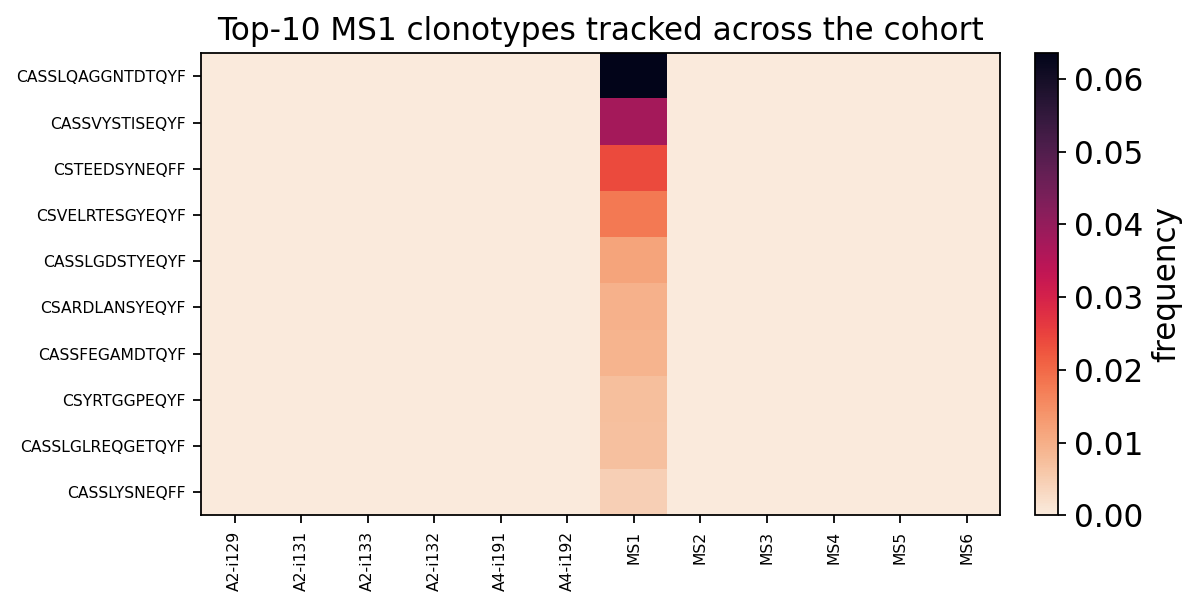

In [24]:
fig, ax = plt.subplots(figsize=(7, 3.8))
im = ax.imshow(track_mat.values, cmap="rocket_r", aspect="auto")
ax.set_xticks(range(track_mat.shape[1]))
ax.set_xticklabels(track_mat.columns, rotation=90, fontsize=7)
ax.set_yticks(range(track_mat.shape[0]))
ax.set_yticklabels(track_mat.index, fontsize=7)
ax.set_title("Top-10 MS1 clonotypes tracked across the cohort")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="frequency")
plt.show()

MS1's dominant clonotypes are **strongly private**: each is hyperexpanded in MS1
itself but essentially absent (frequency ~0) from every other patient and every
healthy control. This is the expected pattern for antigen-driven T-cell
expansions — the *expanded clones* differ between individuals, even when the
repertoire-level statistics (gene usage, public core) are shared.

## 8. CDR3 k-mer composition & motifs

The repertoire-level statistics above treat each clonotype as an atom. But the
CDR3 *sequence itself* carries information — the short amino-acid **k-mers** it
is built from reflect biased V(D)J recombination and antigen-driven selection.
`ov.airr.kmer_analysis` slides a window of length *k* across every CDR3 and
tallies how often each distinct k-mer occurs, per sample — the standard
*immunarch* k-mer statistics. Here we count **5-mers** across the 12-sample
cohort.

In [25]:
kmers = ov.airr.kmer_analysis(immdata, k=5, col="aa")
kmer_total = kmers.set_index("Kmer").sum(axis=1).sort_values(ascending=False)
print(f"distinct 5-mers: {kmers.shape[0]:,}  across {kmers.shape[1] - 1} samples")
kmer_total.head(10).rename("total_occurrences").to_frame()

distinct 5-mers: 172,926  across 12 samples


,total_occurrences
Kmer,
CASSL,13796.0
NEQFF,11897.0
YEQYF,11370.0
ETQYF,10571.0
DTQYF,8535.0
YNEQF,6979.0
CASSP,6391.0
CASSQ,6204.0
TDTQY,5301.0


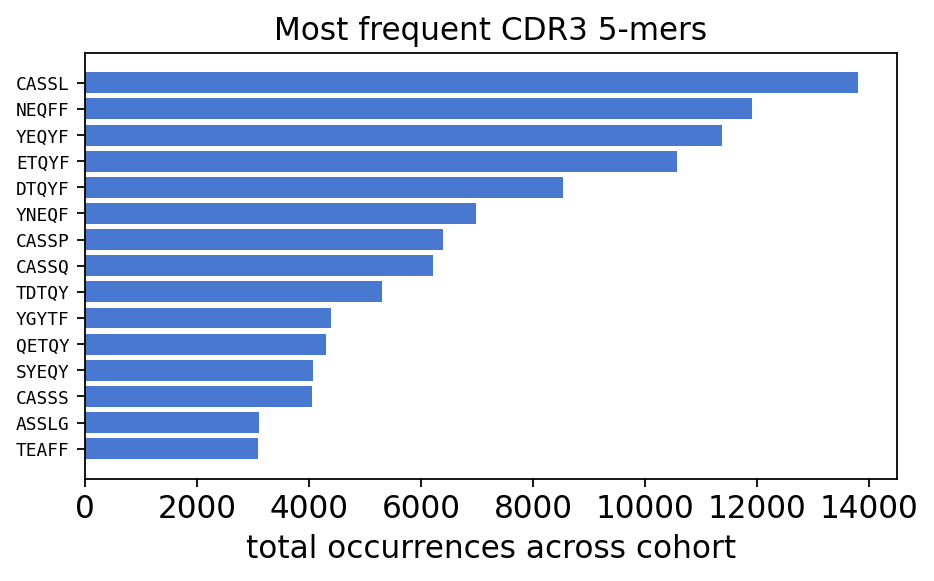

In [26]:
fig, ax = plt.subplots(figsize=(6.5, 3.5))
top_k = kmer_total.head(15)[::-1]
ax.barh(range(len(top_k)), top_k.values, color="#4878cf")
ax.set_yticks(range(len(top_k)))
ax.set_yticklabels(top_k.index, fontsize=8, family="monospace")
ax.set_xlabel("total occurrences across cohort")
ax.set_title("Most frequent CDR3 5-mers")
plt.show()

### From k-mers to a sequence-logo motif

`ov.airr.kmer_motif` collapses the multi-sample k-mer table into a single set
of weighted k-mers and computes a **per-position residue profile** — a position
frequency matrix (`method='freq'`) or, with `method='wei'`, a position weight
matrix (`log2` enrichment over background). `ov.airr.kmer_motif_plot` then draws
the profile as a stacked-bar sequence logo: tall, single-colour stacks mark
positions dominated by one amino acid.

In [27]:
pfm = ov.airr.kmer_motif(kmers, method="freq")
pwm = ov.airr.kmer_motif(kmers, method="wei")
print(f"motif profile: {pfm.shape[0]} amino acids x {pfm.shape[1]} positions")
dominant = pfm.idxmax()
print("dominant residue per position:", dict(dominant))

motif profile: 20 amino acids x 5 positions
dominant residue per position: {'V1': 'S', 'V2': 'S', 'V3': 'S', 'V4': 'G', 'V5': 'F'}


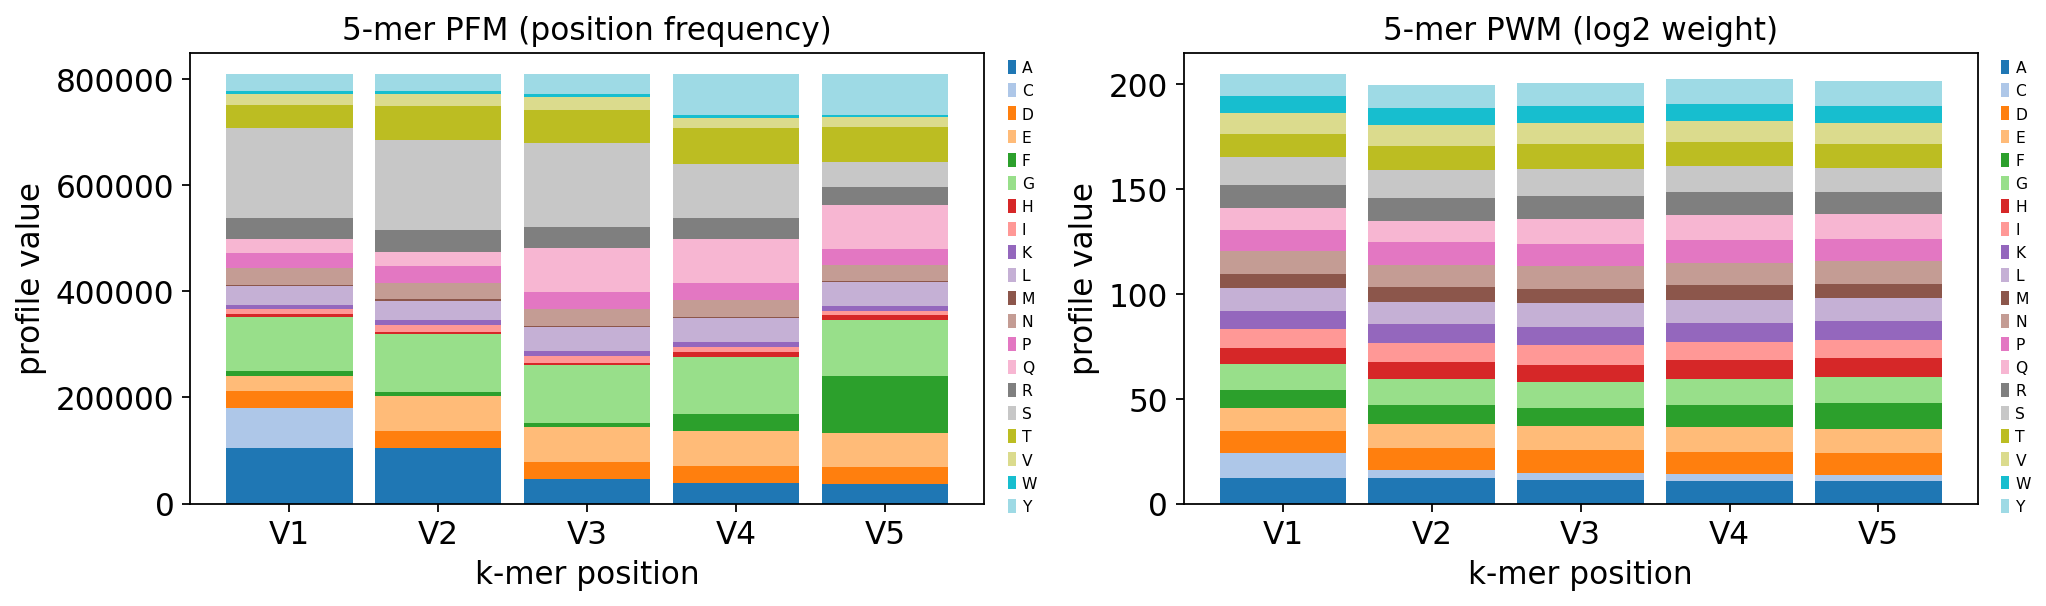

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ov.airr.kmer_motif_plot(pfm, ax=axes[0], title="5-mer PFM (position frequency)")
ov.airr.kmer_motif_plot(pwm, ax=axes[1], title="5-mer PWM (log2 weight)")
plt.tight_layout()
plt.show()

The 5-mer motif is **not flat**: glycine (G) and serine (S) dominate the
profile, with alanine and aspartate also enriched — exactly the small, flexible
residues that the germline-encoded CASS… stretch and the N/P-addition region of
TCR-beta CDR3s are built from. The PWM (right) re-expresses this as enrichment
over a uniform background, making the G/S bias unmistakable. This sequence-level
fingerprint is shared across the whole cohort, regardless of disease status.

## 9. CDR3 amino-acid physicochemical profile

A motif logo summarises *which* residues appear; the **physicochemical profile**
asks what those residues *do*. The middle of the CDR3 loop — the part that
actually contacts antigen — is generated by non-templated N/P additions, so its
**hydrophobicity, charge and volume** are tuneable knobs of antigen recognition.
`ov.airr.cdr3_aa_properties` builds, for one repertoire, a per-position average
of a chosen property from `pyimmunarch.AA_PROPERTIES` (`hydropathy`, `charge`,
`volume`).

In [29]:
prop_table = ov.airr.cdr3_aa_properties(
    immdata, sample="MS1", property=["hydropathy", "charge", "volume"],
    max_len=18, align="left")
print("MS1 CDR3 length used:", prop_table.shape[1], "positions")
prop_table.T.round(2).head(8)


MS1 CDR3 length used: 18 positions


,hydropathy,charge,volume
P1,2.50,0.00,108.50
P2,1.25,0.00,88.76
P3,0.10,0.00,97.38
P4,-1.19,0.07,104.19
P5,-0.39,-0.02,136.48
P6,-0.78,-0.02,115.71
P7,-0.69,0.01,112.58
P8,-0.81,-0.01,110.20


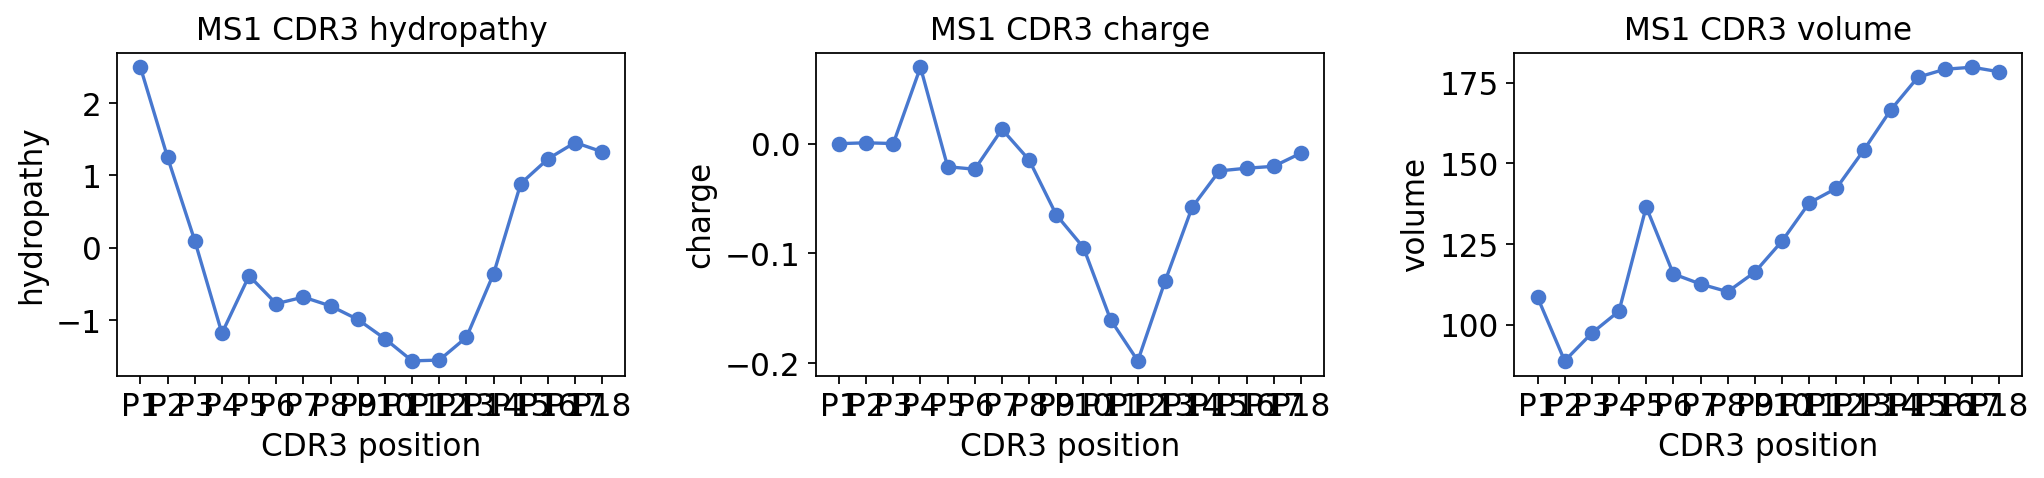

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, prop in zip(axes, ["hydropathy", "charge", "volume"]):
    prof = ov.airr.cdr3_aa_properties(immdata, sample="MS1", property=prop,
                                      max_len=18, align="left")
    ov.airr.cdr3_aa_profile_plot(prof, ax=ax, title=f"MS1 CDR3 {prop}")
plt.tight_layout()
plt.show()

### Composition profile and an MS-vs-healthy property comparison

Dropping the `property` argument returns the raw **per-position amino-acid
composition** — a stacked-bar logo of the whole repertoire. We also pool a
property profile across each group to ask whether MS and healthy CDR3 loops
differ in their physicochemistry.

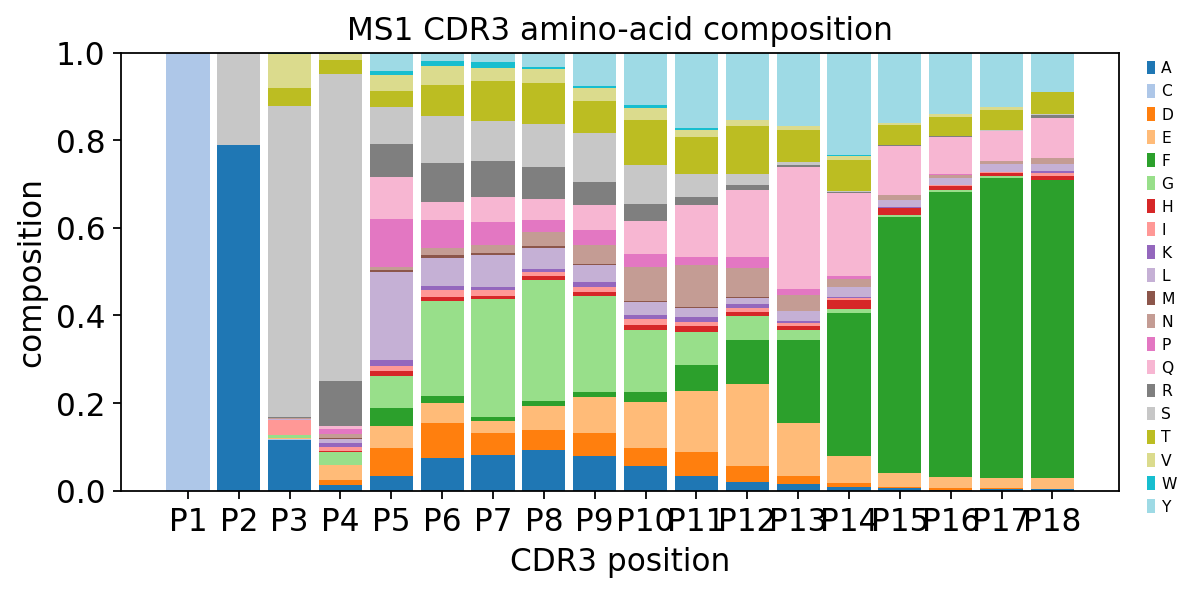

In [31]:
comp = ov.airr.cdr3_aa_properties(immdata, sample="MS1", max_len=18, align="left")
ax = ov.airr.cdr3_aa_profile_plot(comp, figsize=(8, 3.6),
                                  title="MS1 CDR3 amino-acid composition")
plt.show()

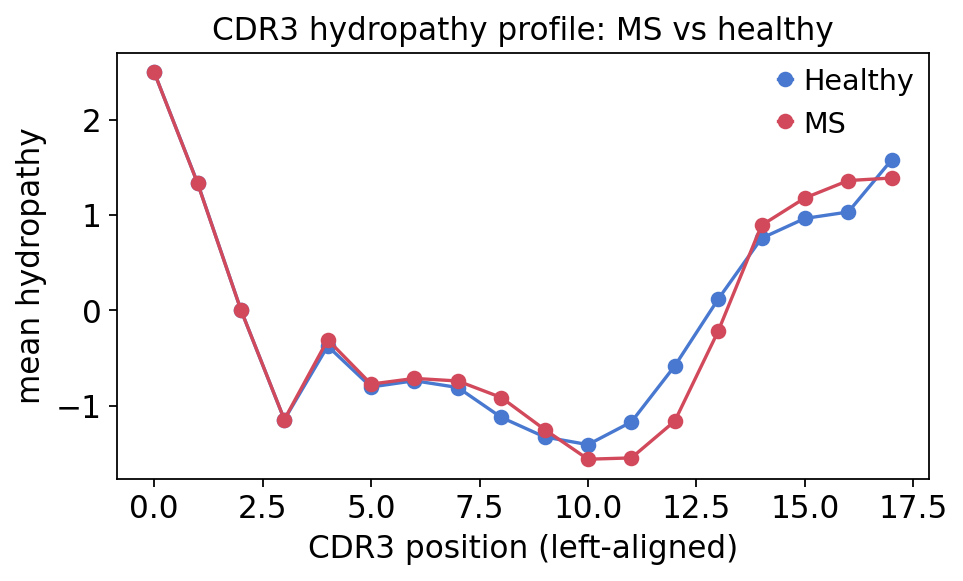

In [32]:
hyd = ov.airr.cdr3_aa_properties_by_group(
    immdata, groups=cohort["groups"], property="hydropathy", max_len=18)
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.plot(range(len(hyd)), hyd["Healthy"].values, "o-",
        color=colors["Healthy"], label="Healthy")
ax.plot(range(len(hyd)), hyd["MS"].values, "o-",
        color=colors["MS"], label="MS")
ax.set(xlabel="CDR3 position (left-aligned)", ylabel="mean hydropathy",
       title="CDR3 hydropathy profile: MS vs healthy")
ax.legend(frameon=False)
plt.show()


The CDR3 hydropathy profile has the canonical shape — hydrophobic, conserved
flanks (the germline C-terminal F/W anchor and the N-terminal CAS… stretch) and
a more hydrophilic, variable centre, which is the antigen-contacting loop tip.
The MS and healthy curves track each other almost exactly: at the bulk level the
**physicochemical grammar of the CDR3 loop is conserved** in MS. As with the
spectratype, the disease signal is not a gross sequence-chemistry defect.

## 10. Multivariate gene-usage analysis

Section 6 ranked individual TRBV segments. But gene usage is a **multivariate**
fingerprint — each sample is a point in ~50-dimensional V-segment space.
`ov.airr.gene_usage_analysis` takes the `gene_usage_bulk` table and, in one call,
computes a sample-by-sample **Jensen-Shannon distance** matrix, embeds the
samples in 2-D (MDS), clusters them, and — given group labels — runs a per-gene
**Kruskal-Wallis** test for differential usage. The question: do MS samples
form their own cluster in V-gene-usage space?

In [33]:
groups = dict(zip(meta["Sample"], meta["group"]))
gu_res = ov.airr.gene_usage_analysis(gene_usage, distance="js", reduction="mds",
                                     cluster="hclust", k=2, groups=groups)
print("result keys:", list(gu_res.keys()))
emb = gu_res["embedding"].join(pd.Series(groups, name="group"))
emb.join(gu_res["clusters"]).round(3)

result keys: ['distance', 'embedding', 'clusters', 'kruskal']


,DimI,DimII,group,Cluster
A2-i129,0.024,-0.018,Healthy,2
A2-i131,0.020,0.027,Healthy,1
A2-i132,-0.014,0.038,Healthy,1
A2-i133,0.000,0.044,Healthy,1
A4-i191,-0.028,-0.026,Healthy,2
A4-i192,-0.028,0.021,Healthy,1
MS1,-0.005,-0.004,MS,1
MS2,0.039,-0.013,MS,2
MS3,-0.016,0.001,MS,1
MS4,0.017,-0.016,MS,2


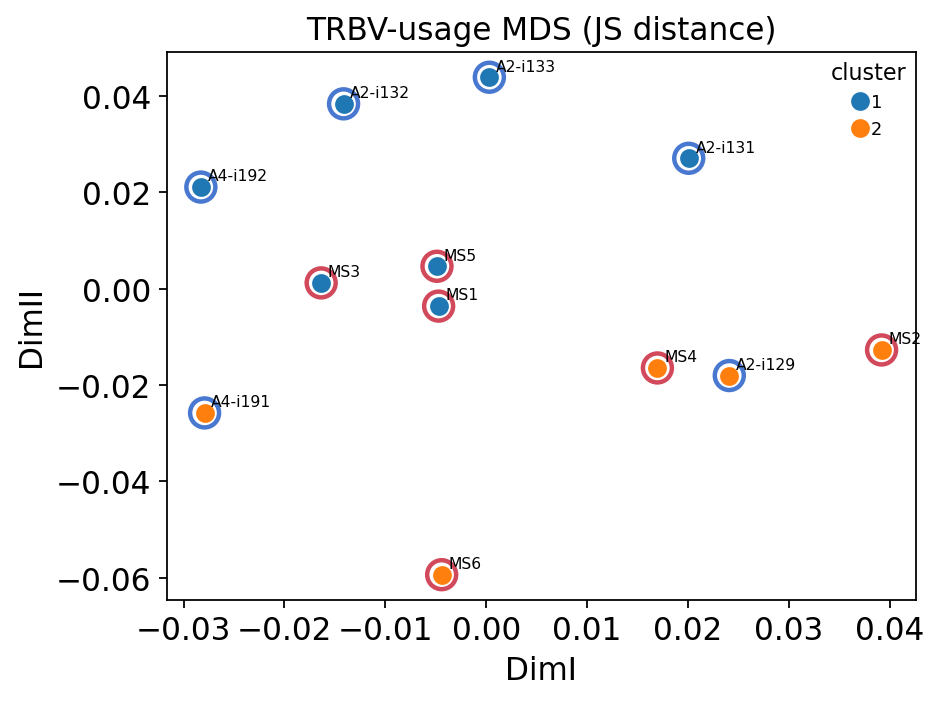

In [34]:
ax = ov.airr.gene_usage_analysis_plot(gu_res, figsize=(6, 4.5),
                                      title="TRBV-usage MDS (JS distance)")
for s, (x, y) in gu_res["embedding"].iterrows():
    ax.scatter(x, y, s=170, facecolors="none",
               edgecolors=colors[groups[s]], linewidths=2, zorder=1)
plt.show()

In [35]:
kw = gu_res["kruskal"].dropna().head(10).copy()
kw["signif"] = np.where(kw["p_value"] < 0.05, "*", "")
print(f"genes tested: {gu_res['kruskal']['p_value'].notna().sum()}  "
      f"| nominally significant (p<0.05): {(gu_res['kruskal']['p_value'] < 0.05).sum()}")
kw.round(4)

genes tested: 48  | nominally significant (p<0.05): 9


,Gene,statistic,p_value,signif
0,TRBV5-6,8.3077,0.0039,*
1,TRBV25-1,7.4103,0.0065,*
2,TRBV2,6.5641,0.0104,*
3,TRBV13,5.0256,0.0250,*
4,TRBV21-1,5.0256,0.0250,*
5,TRBV9,5.0256,0.0250,*
6,TRBV6-5,4.3333,0.0374,*
7,TRBV5-1,4.3333,0.0374,*
8,TRBV4-3,4.0333,0.0446,*
9,TRBV7-9,3.6923,0.0547,


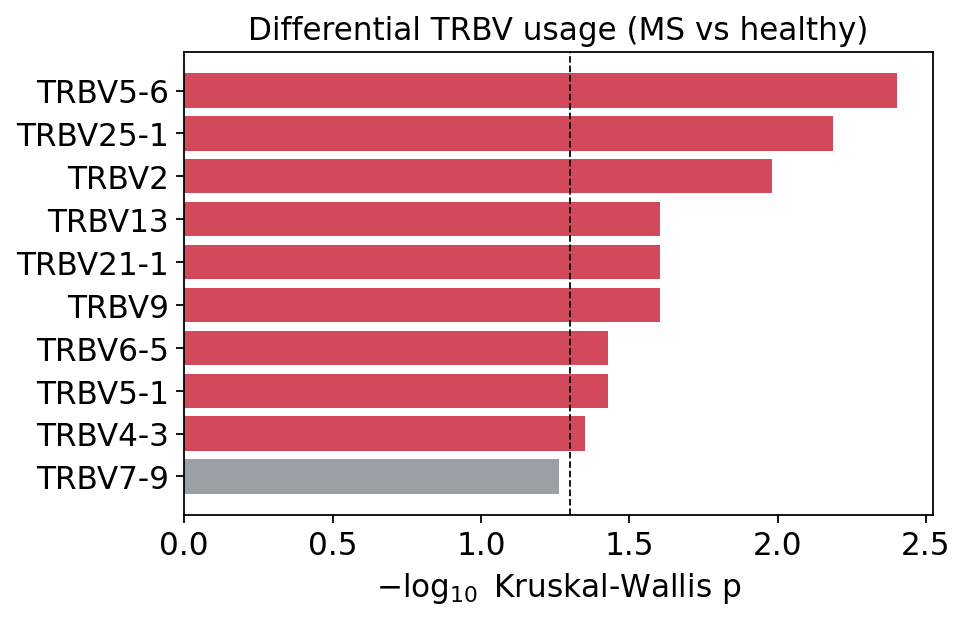

In [36]:
fig, ax = plt.subplots(figsize=(6, 3.8))
kw_plot = gu_res["kruskal"].dropna().head(10)[::-1]
bar_col = ["#d1495b" if p < 0.05 else "#9aa0a6" for p in kw_plot["p_value"]]
ax.barh(range(len(kw_plot)), -np.log10(kw_plot["p_value"]), color=bar_col)
ax.set_yticks(range(len(kw_plot)))
ax.set_yticklabels(kw_plot["Gene"])
ax.axvline(-np.log10(0.05), color="black", ls="--", lw=0.8)
ax.set_xlabel(r"$-\log_{10}$ Kruskal-Wallis p")
ax.set_title("Differential TRBV usage (MS vs healthy)")
plt.show()

The MDS embedding shows that MS and healthy samples are **not cleanly
separated** in global V-gene-usage space — the unsupervised 2-cluster split does
not recover the disease labels, confirming that the bulk repertoire is
*quantitatively* rather than *categorically* perturbed. The Kruskal-Wallis test
nonetheless flags a handful of individual segments (e.g. **TRBV5-6, TRBV25-1,
TRBV2**) with nominally significant MS-vs-healthy differences, consistent with
the differential-usage barplot of section 6. The signal is real but distributed
across a few segments, not a wholesale rewiring of V-gene choice.

## 11. Repertoire-overlap structure

The pairwise overlap heatmap of section 5 is hard to read as a whole. The same
sample-by-sample matrix can be turned into an **ordination**:
`ov.airr.overlap_analysis` embeds the overlap matrix in 2-D (MDS) and clusters
the samples — the *immunarch* `repOverlapAnalysis` workflow. If MS patients
shared more clonotypes with each other than with controls, they would cluster
apart here.

In [37]:
ov_res = ov.airr.overlap_analysis(overlap.fillna(0.0), method="mds+hclust", k=2)
print("overlap-analysis keys:", list(ov_res.keys()))
ov_emb = ov_res["coords"].join(pd.Series(groups, name="group")).join(ov_res["clusters"])
ov_emb.round(2)

overlap-analysis keys: ['coords', 'clusters']


,DimI,DimII,group,Cluster
A2-i129,-5.56,24.63,Healthy,2
A2-i131,-19.17,22.04,Healthy,2
A2-i133,-0.19,14.27,Healthy,2
A2-i132,-1.32,6.95,Healthy,2
A4-i191,23.27,0.82,Healthy,2
A4-i192,-14.48,1.63,Healthy,2
MS1,-15.24,-30.50,MS,1
MS2,28.13,33.74,MS,2
MS3,39.25,-20.83,MS,2
MS4,-37.21,-19.24,MS,1


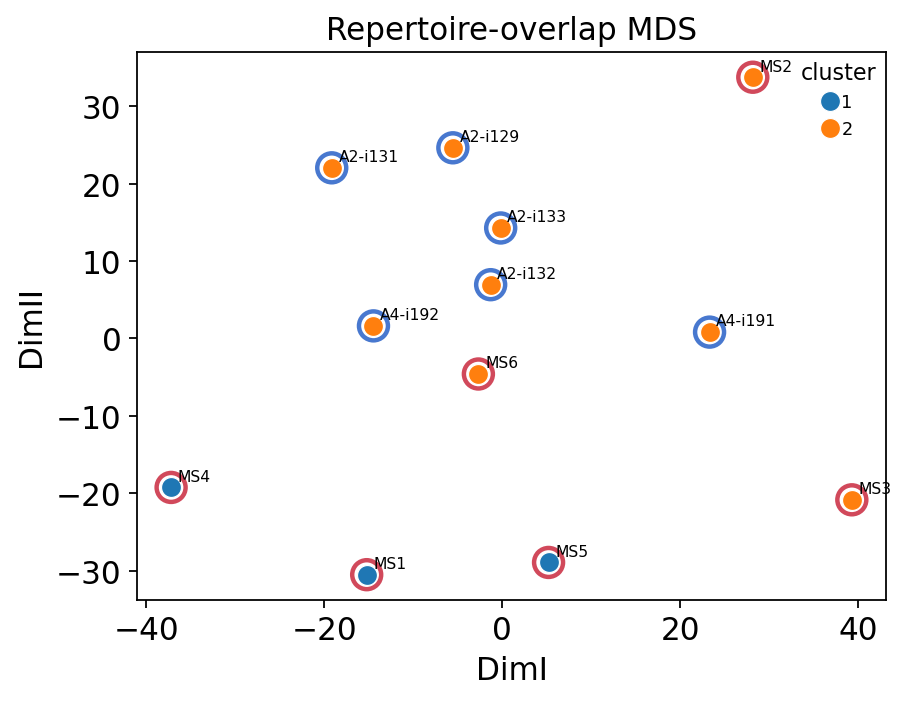

In [38]:
ax = ov.airr.gene_usage_analysis_plot(ov_res, figsize=(6, 4.5),
                                      title="Repertoire-overlap MDS")
for s, (x, y) in ov_res["coords"].iterrows():
    ax.scatter(x, y, s=170, facecolors="none",
               edgecolors=colors[groups[s]], linewidths=2, zorder=1)
plt.show()

In [39]:
cross = pd.crosstab(ov_emb["group"], ov_emb["Cluster"])
purity, agree = ov.airr.cluster_purity(ov_emb["Cluster"], ov_emb["group"],
                                       ignore_label=None)
print("group x overlap-cluster contingency:")
print(cross)
print(f"\nbest cluster-vs-group agreement: {agree:.0%}")


group x overlap-cluster contingency:
Cluster  1  2
group        
Healthy  0  6
MS       3  3

best cluster-vs-group agreement: 75%


The overlap-based ordination tells the same story as the gene-usage MDS: MS
and healthy samples are **interleaved**, and the unsupervised clustering does not
recover disease status. This is expected — repertoire overlap in unrelated
individuals is dominated by convergent *public* clonotypes (section 5), which are
shared irrespective of MS, so it carries little disease signal. Sample structure
in this cohort is driven more by sequencing lane / cohort batch than by
diagnosis.

## 12. The public-repertoire workflow

`ov.airr.public_clonotypes` (section 5) built the raw shared-clonotype table.
`ov.airr.public_repertoire` is the full *immunarch* public-repertoire workflow:
it can **build** the table, **filter** it to a metadata-defined subset
(`filter_by`), **summarise** the sample-incidence distribution (`statistics`)
and **compare** two public repertoires clonotype-by-clonotype (`compare_to`).
Here we build separate MS and healthy public repertoires and compare them.

In [40]:
pr_ms = ov.airr.public_repertoire(immdata, col="aa+v", filter_by={"Status": "MS"})
pr_hc = ov.airr.public_repertoire(immdata, col="aa+v", filter_by={"Status": "C"})
print(f"MS public repertoire     : {pr_ms.shape[0]:,} clonotypes")
print(f"healthy public repertoire: {pr_hc.shape[0]:,} clonotypes")
pr_ms.sort_values("Samples", ascending=False).head(6)

MS public repertoire     : 38,579 clonotypes
healthy public repertoire: 36,141 clonotypes


,CDR3.aa,V.name,Samples,MS1,MS2,MS3,MS4,MS5,MS6
0,CASSLEETQYF,TRBV5-1,4,NaN,NaN,1.0,1.0,1.0,1.0
15,CASSGTSGSTDTQYF,TRBV6-4,3,1.0,NaN,NaN,1.0,NaN,4.0
16,CASSLAGGYNEQFF,TRBV5-1,3,1.0,NaN,NaN,2.0,6.0,NaN
63,CASSSAGAYNEQFF,TRBV5-1,3,1.0,NaN,NaN,1.0,1.0,NaN
34,CASSLAGGYTEAFF,TRBV5-1,3,1.0,NaN,NaN,2.0,3.0,NaN
32,CASSFTDTQYF,TRBV7-9,3,1.0,NaN,NaN,NaN,1.0,2.0


In [41]:
ms_stats = ov.airr.public_repertoire(immdata, col="aa+v",
                                     filter_by={"Status": "MS"}, statistics=True)
shared_within_ms = ms_stats["statistics"]
print(f"MS-shared clonotype groups: {shared_within_ms.shape[0]}")
print(f"top MS-internal sharing: {shared_within_ms['Count'].max()} clonotypes "
      f"in pair {shared_within_ms.iloc[0]['Group']}")
shared_within_ms.head(8)

MS-shared clonotype groups: 26
top MS-internal sharing: 11 clonotypes in pair MS1&MS4


,Group,Count
0,MS1&MS4,11
1,MS4&MS5,11
2,MS4&MS6,9
3,MS1&MS5,9
4,MS5&MS6,9
5,MS2&MS3,8
6,MS3&MS6,8
7,MS1&MS3,7


In [42]:
cmp = ov.airr.public_repertoire(immdata, col="aa+v",
                                filter_by={"Status": "MS"}, compare_to=pr_hc)
comparison = cmp["comparison"]
print(f"clonotypes public in BOTH MS and healthy: {comparison.shape[0]}")
print(f"columns: {list(comparison.columns)}")
comparison.sort_values("Samples", ascending=False).head(8)

clonotypes public in BOTH MS and healthy: 276
columns: ['CDR3.aa', 'V.name', 'Quant.x', 'Quant.y', 'Samples', 'Result']


,CDR3.aa,V.name,Quant.x,Quant.y,Samples,Result
0,CASSLEETQYF,TRBV5-1,1.000000,1.500000,8,0.000000
3,CASSLGETQYF,TRBV12-4,1.333333,3.000000,6,0.261860
2,CASSFQETQYF,TRBV5-1,1.000000,1.666667,6,0.000000
1,CASSDSSGGANEQFF,TRBV6-4,7.000000,1.750000,6,3.477225
7,CASSLQETQYF,TRBV5-1,1.000000,1.000000,5,NaN
4,CASSDSGGSYNEQFF,TRBV6-4,1.000000,2.000000,5,0.000000
8,CASSSYNEQFF,TRBV12-4,1.000000,1.000000,5,NaN
5,CASSDSSGSTDTQYF,TRBV6-4,1.500000,2.000000,5,0.584963


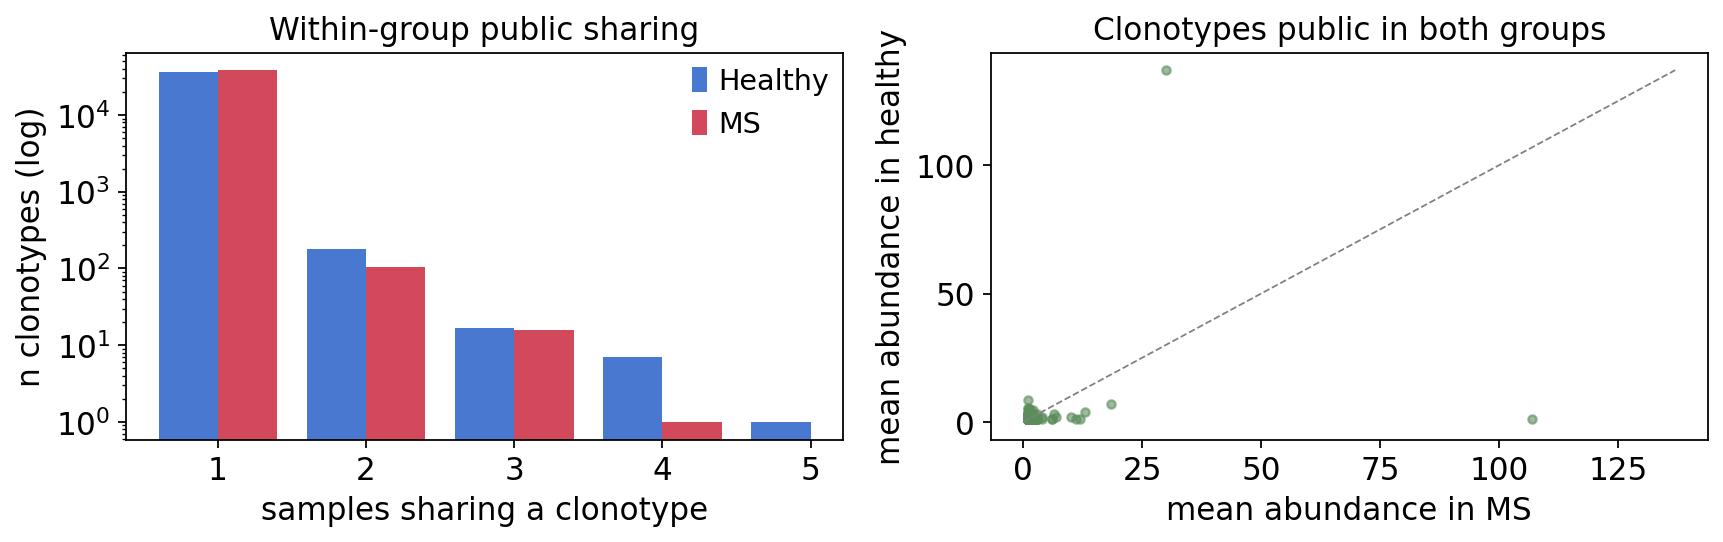

In [43]:
inc_ms = pr_ms["Samples"].value_counts().sort_index()
inc_hc = pr_hc["Samples"].value_counts().sort_index()
lim = max(comparison["Quant.x"].max(), comparison["Quant.y"].max())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
w = 0.4
axes[0].bar(inc_hc.index - w / 2, inc_hc.values, w,
            color=colors["Healthy"], label="Healthy")
axes[0].bar(inc_ms.index + w / 2, inc_ms.values, w,
            color=colors["MS"], label="MS")
axes[0].set(yscale="log", xlabel="samples sharing a clonotype",
            ylabel="n clonotypes (log)", title="Within-group public sharing")
axes[0].legend(frameon=False)
axes[1].scatter(comparison["Quant.x"], comparison["Quant.y"], s=14,
                color="#5b8c5a", alpha=0.6)
axes[1].plot([0, lim], [0, lim], "--", color="grey", lw=0.8)
axes[1].set(xlabel="mean abundance in MS", ylabel="mean abundance in healthy",
            title="Clonotypes public in both groups")
plt.tight_layout()
plt.show()


Each group has thousands of *internally* public clonotypes, but the
cross-group comparison finds only a few hundred clonotypes that are public in
**both** MS and healthy — and for those, the MS-vs-healthy abundance scatter
hugs the diagonal. The shared public core is therefore **status-agnostic**:
clonotypes public enough to recur across many people are convergent-recombination
products, not MS-associated. A genuine MS public signature would have to be
sought among rarer, group-restricted clonotypes.

## 13. Antigen-specificity annotation

A CDR3 sequence becomes biologically interpretable when it can be matched to a
**known antigen**. Curated databases — **VDJdb**, **McPAS-TCR**, TBAdb/PIRD —
list TCR CDR3s with experimentally determined epitope specificities.
`ov.airr.annotate_antigen_bulk` matches every repertoire against such a database
(`pyimmunarch.dbAnnotate`) and counts, per sample, how often each annotated
clonotype occurs.

Here we use the **real VDJdb** — the antigenomics-curated TCR–epitope database —
shipped as an omicverse dataset loader, `ov.datasets.vdjdb_reference()`. It
returns a `pandas.DataFrame` of ~132k human TCR records (TRB and TRA chains)
with CDR3 sequences, V/J calls, epitopes, antigen genes, source species
(CMV, EBV, Influenza, SARS-CoV-2, …), MHC restriction and a VDJdb confidence
score. Because `annotate_antigen_bulk` accepts an already-loaded DataFrame
directly via `db=`, no file path or format string is needed.

In [44]:
vdjdb = ov.datasets.vdjdb_reference()
print(f"real VDJdb: {vdjdb.shape[0]:,} TCR-epitope records, {vdjdb.shape[1]} columns")
print(vdjdb["gene"].value_counts().to_string())
# the cohort is bulk TCR-beta, so keep only the TRB records of VDJdb
vdjdb_trb = vdjdb[vdjdb["gene"] == "TRB"].copy()
print(f"\nTRB subset used for annotation: {vdjdb_trb.shape[0]:,} records")
vdjdb_trb[["cdr3_aa", "v_call", "antigen_epitope",
           "antigen_gene", "antigen_species", "vdjdb_score"]].head(5)

🔍 Downloading data to ./data/vdjdb_reference.tsv.gz
⚠️ File ./data/vdjdb_reference.tsv.gz already exists
real VDJdb: 132,204 TCR-epitope records, 10 columns
gene
TRB    87992
TRA    44212

TRB subset used for annotation: 87,992 records


,cdr3_aa,v_call,antigen_epitope,antigen_gene,antigen_species,vdjdb_score
44212,CAINPGTAYGYTF,TRBV10-3*01,KPYSGTAYNAL,HEXON,AdV,0
44213,CASSPGTPEQFF,TRBV18*01,KPYSGTAYNAL,HEXON,AdV,0
44214,CSARPGLADEQFF,TRBV10-3*01,KPYSGTAYNAL,HEXON,AdV,0
44215,CASNDYDNEQFF,TRBV5-1*01,TDLGQNLLY,HEXON,AdV,0
44216,CASNLADDEQFF,TRBV5-1*01,TDLGQNLLY,HEXON,AdV,0


In [45]:
ann = ov.airr.annotate_antigen_bulk(immdata, db=vdjdb_trb,
                                   data_col="CDR3.aa", db_col="cdr3_aa")
print(f"cohort clonotypes matching VDJdb: {ann.attrs['n_matched']:,} "
      f"(of {ann.attrs['n_query']:,} unique CDR3.aa - a "
      f"{ann.attrs['hit_rate']:.1%} hit rate)")
ann[["CDR3.aa", "Species", "Antigen", "Epitope", "Samples", "total_clones"]] \
    .sort_values("total_clones", ascending=False).head(8)


cohort clonotypes matching VDJdb: 1,615 (of 76,105 unique CDR3.aa - a 2.1% hit rate)


,CDR3.aa,Species,Antigen,Epitope,Samples,total_clones
301,CASSLGQNTEAFF,EBV,EBNA3A,FLRGRAYGL,2,114.0
135,CASSLGRETQYF,InfluenzaA,NP,LPRRSGAAGA,3,79.0
389,CASSLALDEQFF,CMV,pp65,IPSINVHHY,1,41.0
388,CATSRVAGETQYF,CMV,UL29/28,FRCPRRFCF,1,40.0
1149,CASSLYSNEQFF,EBV,BRLF1,YVLDHLIVV,1,38.0
0,CASSLGETQYF,CMV,IE1,KLGGALQAK,11,37.0
1,CASSLEETQYF,CMV,pp65,LLQTGIHVRVSQPSL,11,27.0
62,CASSLDSYEQYF,HIV-1,Gag,KRWIILGLNK,4,22.0


In [46]:
sample_cols = hc_samples + ms_samples
load = ov.airr.antigen_load_summary(ann, sample_cols=sample_cols,
                                    groups=cohort["groups"])
by_species = load["by_species"].tail(8)
ag_by_sample = load["species_by_sample"].loc[by_species.index, sample_cols]
print("total VDJdb-annotated clones per group:")
print(load["by_group"].round(0).to_string())


total VDJdb-annotated clones per group:
Healthy    1920.0
MS         1473.0


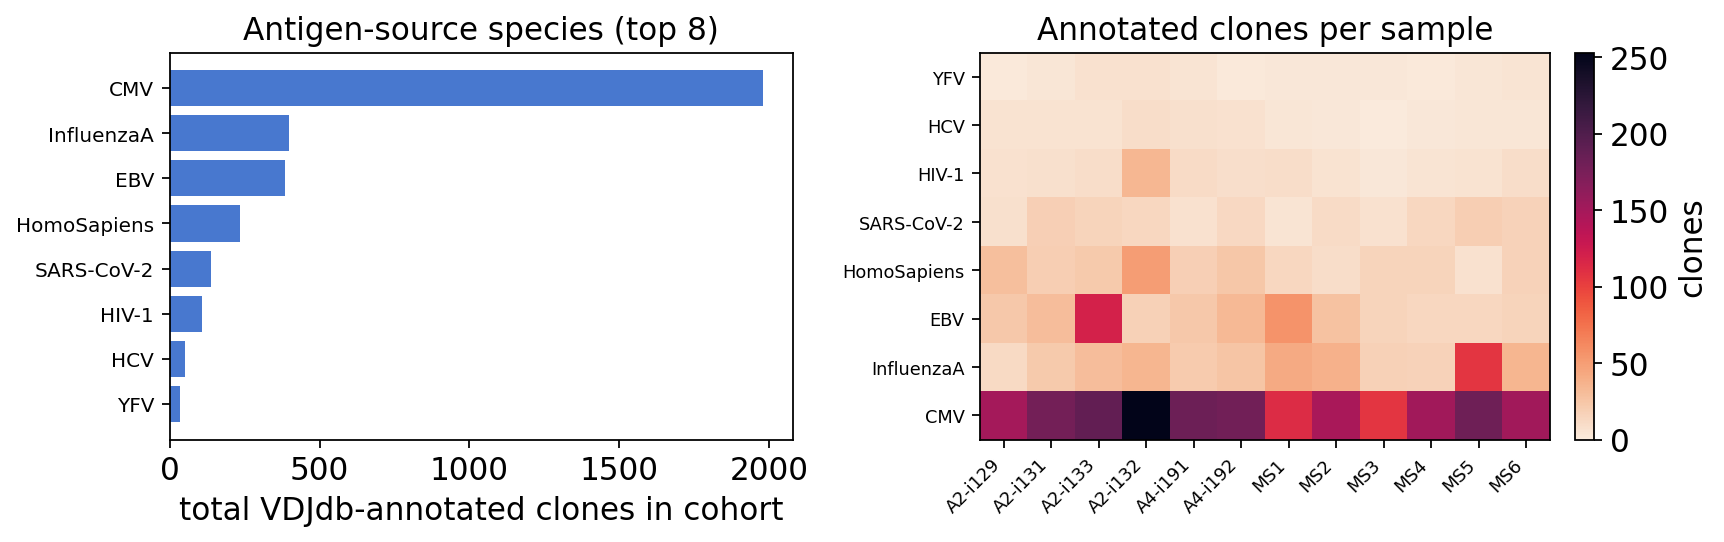

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].barh(range(len(by_species)), by_species.values, color="#4878cf")
axes[0].set_yticks(range(len(by_species)))
axes[0].set_yticklabels(by_species.index, fontsize=9)
axes[0].set_xlabel("total VDJdb-annotated clones in cohort")
axes[0].set_title("Antigen-source species (top 8)")
im = axes[1].imshow(ag_by_sample.values, cmap="rocket_r", aspect="auto")
axes[1].set_xticks(range(ag_by_sample.shape[1]))
axes[1].set_xticklabels(ag_by_sample.columns, rotation=45, ha="right", fontsize=8)
axes[1].set_yticks(range(ag_by_sample.shape[0]))
axes[1].set_yticklabels(ag_by_sample.index, fontsize=8)
axes[1].set_title("Annotated clones per sample")
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, label="clones")
plt.tight_layout()
plt.show()


Matching the bulk MS-vs-healthy repertoires against the **real VDJdb** is, as
expected, a *modest-yield* exercise: only about **2%** of the cohort's unique
TCR-beta CDR3s map to an experimentally characterised epitope — VDJdb covers a
small, virus-biased slice of the vast TCR space. Of the ~1.6k matched
clonotypes, the annotated clone load is dominated by **CMV** (epitopes
`NLVPMVATV` and `KLGGALQAK`), followed by **Influenza A** (`GILGFVFTL`) and
**EBV** — the most public, most convergent anti-viral TCR-beta sequences in any
human cohort. SARS-CoV-2 and a few human (`HomoSapiens`) self-antigen records
also appear. The per-sample heatmap shows these viral-specific clones are spread
across both MS patients and healthy controls with **no clear disease
enrichment** — unsurprising for ubiquitous chronic-viral immunity, and a useful
honest baseline before testing whether any specific antigen class is
over-represented in disease.

## 14. Synthesis - the MS-vs-healthy repertoire comparison

Running the full `ov.airr` bulk pipeline on the 12-sample TCR-beta cohort gives
a coherent picture of the MS peripheral T-cell repertoire:

| Axis | Tool | MS vs healthy finding |
|---|---|---|
| **Structure** | spectratype | Polyclonal in both groups; canonical 14-15 aa peak - no gross distortion. |
| **Clonality** | `clonality` | MS repertoires carry larger, more variable **hyperexpanded** clonal space. |
| **Diversity** | `repertoire_diversity` | Chao1 richness *higher* on average in MS but far more heterogeneous (MS3 extreme); D50 larger in MS. |
| **Public core** | `public_clonotypes` | Mostly private clonotypes; a small public core shared *regardless* of disease. |
| **Gene usage** | `gene_usage_bulk` | Biased TRBV usage - **TRBV5-1 / TRBV12-4 up in MS**, TRBV4-3 / TRBV9 up in healthy. |
| **Clonal tracking** | `track_clonotypes` | A patient's top expansions are private to that patient. |
| **K-mer / motif** | `kmer_analysis` / `kmer_motif` | CDR3 5-mers carry a strong G/S-rich motif, shared across the whole cohort. |
| **CDR3 chemistry** | `cdr3_aa_properties` | Conserved hydrophobic flanks, hydrophilic loop tip; near-identical MS vs healthy. |
| **Multivariate usage** | `gene_usage_analysis` | MS and healthy do **not** separate in V-usage MDS; a few segments are KW-significant. |
| **Overlap structure** | `overlap_analysis` | Samples interleave in overlap MDS - sharing is status-agnostic. |
| **Public workflow** | `public_repertoire` | The cross-group public core hugs the diagonal - public = convergent, not MS-specific. |
| **Antigen DB** | `annotate_antigen_bulk` | Matched clonotypes are dominated by public anti-viral (CMV / influenza) TCRs. |

**Interpretation.** MS repertoires are *not* simply less diverse. They are
**more heterogeneous** - high underlying richness combined with patient-specific
clonal expansions and a measurable bias in V-gene usage. Every unsupervised view
(gene-usage MDS, overlap MDS, public-repertoire comparison) shows MS and healthy
samples interleaved, so the disease signal is **quantitative and distributed**,
not a categorical repertoire defect. It lives at the level of clonal expansion
and germline-segment selection, while the sequence grammar of the CDR3 (k-mer
motifs, physicochemical profile) and the public-clonotype core are conserved.
This is the canonical autoimmune-repertoire signature, and `ov.airr` reproduces
it end-to-end from one `ImmunData` object.

**See also.** `t_airr_01_*` for the single-cell TCR/BCR side of `ov.airr`
(`read_10x_vdj`, `define_clonotypes`, `clonotype_network`), and the B-cell SHM /
lineage backends (`clonal_clustering`, `mutation_analysis`, `lineage_trees`).